# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3.   Use only numpy for PCA; matplotlib is allowed for visualizations.

**GitHub repository:** https://github.com/Ntagungira-cmd/PCA

## Context: Africa Economic, Banking and Systemic Crisis Data
The dataset specifically focuses on the Banking, Debt, Financial, Inflation and Systemic Crises that occurred, from 1860 to 2014, in 13 African countries, including: Algeria, Angola, Central African Republic, Ivory Coast, Egypt, Kenya, Mauritius, Morocco, Nigeria, South Africa, Tunisia, Zambia and Zimbabwe.

| Requirement | Status | Details |
|-------------|--------|---------|
| **Africanized** | ✅ Pass | Focuses entirely on the economic histories of 13 African countries. |
| **7+ Columns** | ✅ Pass | Contains 14 distinct features (e.g., `exch_usd`, `inflation_annual_cpi`, `domestic_debt_in_default`). |
| **Non-Numeric** | ✅ Pass | Includes string/categorical columns like `country`, `cc3` (country code), and `banking_crisis` (text labels). |
| **Not Generic** | ✅ Pass | Completely avoids the banned "housing/wine" clichés and tackles real macroeconomics. |
| **Missing Values** | ✅ Pass | 52 `NaN` values in `inflation_annual_cpi`; handled via mean imputation. |


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

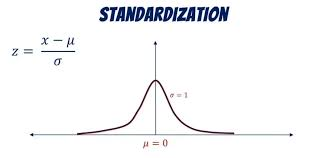


### Imports

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

print(f'numpy {np.__version__}, matplotlib {plt.matplotlib.__version__}')

numpy 2.3.5, matplotlib 3.10.6


In [2]:
# Step 1a: Load the African economic crises dataset (numpy only)
raw_data = np.genfromtxt('data/african_crises.csv', delimiter=',', dtype=str, skip_header=1)
print(f'Raw data shape: {raw_data.shape}')
print(f'Non-numeric columns retained in raw file: country={raw_data[0, 2]}, banking_crisis={raw_data[0, 13]}')
raw_data[:3]

Raw data shape: (1059, 14)
Non-numeric columns retained in raw file: country=Algeria, banking_crisis=crisis


array([['1', 'DZA', 'Algeria', '1870', '1', '0.052264', '0', '0', '0',
        '3.441455696', '0', '0', '0', 'crisis'],
       ['1', 'DZA', 'Algeria', '1871', '0', '0.052798', '0', '0', '0',
        '14.14913958', '0', '0', '0', 'no_crisis'],
       ['1', 'DZA', 'Algeria', '1872', '0', '0.052274', '0', '0', '0',
        '-3.718592965', '0', '0', '0', 'no_crisis']], dtype='<U24')

In [3]:
# Step 1b: Encode non-numeric features and impute missing values
numeric_column_indices = [0, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
feature_names = [
    'case', 'year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default',
    'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi',
    'independence', 'currency_crises', 'inflation_crises'
]
data = raw_data[:, numeric_column_indices].astype(float)
print(f'Missing values before imputation: {np.isnan(data).sum()}')

# Binary encoding for banking_crisis (crisis=1, no_crisis=0)
banking_crisis = raw_data[:, 13]
banking_encoded = np.where(banking_crisis == 'crisis', 1.0, 0.0)

# Label encoding for country (13 African countries -> integer IDs)
countries = raw_data[:, 2]
unique_countries = np.unique(countries)
country_to_id = {country: idx for idx, country in enumerate(unique_countries)}
country_encoded = np.array([country_to_id[c] for c in countries], dtype=float)

data = np.column_stack([data, banking_encoded, country_encoded])
feature_names.extend(['banking_crisis_encoded', 'country_encoded'])

# Mean imputation for inflation_annual_cpi (only column with NaN values)
inflation_idx = feature_names.index('inflation_annual_cpi')
inflation_col = data[:, inflation_idx]
nan_mask = np.isnan(inflation_col)
inflation_mean = np.nanmean(inflation_col)
data[nan_mask, inflation_idx] = inflation_mean

print(f'Encoded banking_crisis and country; imputed {nan_mask.sum()} inflation NaNs with mean={inflation_mean:.4f}')
print(f'Final feature matrix shape: {data.shape}')
print(f'Remaining missing values: {np.isnan(data).sum()}')
data[:5]

Missing values before imputation: 52
Encoded banking_crisis and country; imputed 52 inflation NaNs with mean=88.3369
Final feature matrix shape: (1059, 13)
Remaining missing values: 0


array([[ 1.00000000e+00,  1.87000000e+03,  1.00000000e+00,
         5.22640000e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  3.44145570e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 1.00000000e+00,  1.87100000e+03,  0.00000000e+00,
         5.27980000e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.41491396e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.00000000e+00,  1.87200000e+03,  0.00000000e+00,
         5.22740000e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -3.71859297e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 1.00000000e+00,  1.87300000e+03,  0.00000000e+00,
         5.16800000e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  1.12038970e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e

**Data handling choices:** `banking_crisis` is binary-encoded because it is a two-class label. `country` is label-encoded so regional structure enters PCA numerically; `cc3` is omitted as a duplicate of country. Missing `inflation_annual_cpi` values are mean-imputed to retain all 1059 country-year observations instead of dropping rows.

In [4]:
# Step 1c: Standardize using z-score: X_std = (X - mean) / std
data_mean = np.mean(data, axis=0)
data_std = np.std(data, axis=0, ddof=0)
standardized_data = (data - data_mean) / data_std
standardized_data[:5]

array([[-1.46165598, -2.91715048,  3.45175812, -0.38671252, -0.20321893,
        -0.42497295, -0.14700624, -0.04157633, -1.86235185, -0.37805817,
        -0.38547376,  3.20405328, -1.57145157],
       [-1.46165598, -2.88731291, -0.28970744, -0.38670773, -0.20321893,
        -0.42497295, -0.14700624, -0.03633239, -1.86235185, -0.37805817,
        -0.38547376, -0.31210467, -1.57145157],
       [-1.46165598, -2.85747534, -0.28970744, -0.38671243, -0.20321893,
        -0.42497295, -0.14700624, -0.04508286, -1.86235185, -0.37805817,
        -0.38547376, -0.31210467, -1.57145157],
       [-1.46165598, -2.82763778, -0.28970744, -0.38671776, -0.20321893,
        -0.42497295, -0.14700624, -0.03777478, -1.86235185, -0.37805817,
        -0.38547376, -0.31210467, -1.57145157],
       [-1.46165598, -2.79780021, -0.28970744, -0.3867211 , -0.20321893,
        -0.42497295, -0.14700624, -0.04514651, -1.86235185, -0.37805817,
        -0.38547376, -0.31210467, -1.57145157]])

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [5]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)
cov_matrix

array([[ 1.00094518e+00,  1.15683617e-01,  1.10011949e-02,
        -2.32195168e-01,  1.28479445e-01, -3.92995244e-02,
        -3.30121572e-02,  3.98618284e-02,  2.18786514e-02,
         9.54288127e-02,  6.41150377e-03, -2.36746406e-02,
         9.91489654e-01],
       [ 1.15683617e-01,  1.00094518e+00,  1.97637084e-01,
         2.48992102e-01,  1.36957334e-01,  2.72147122e-01,
        -5.47220570e-02,  4.24842866e-02,  4.07745211e-01,
         1.89569506e-01,  9.87235815e-02,  2.13975718e-01,
         1.35118059e-01],
       [ 1.10011949e-02,  1.97637084e-01,  1.00094518e+00,
         2.02878129e-01,  1.22273959e-01,  2.50086371e-01,
         5.27917570e-03,  1.09999523e-01,  1.47222216e-01,
         1.12857562e-01,  1.72724937e-01,  8.54509081e-01,
         1.56009121e-02],
       [-2.32195168e-01,  2.48992102e-01,  2.02878129e-01,
         1.00094518e+00,  5.25800152e-03,  4.23289736e-01,
        -4.07641704e-02, -1.42611982e-02,  1.26153282e-01,
        -5.65251994e-02, -6.38431799e

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [6]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.0079524 , 0.13260849, 0.25905918, 0.50370055, 0.58286007,
        0.76359349, 0.92075606, 1.00557303, 1.11862102, 1.33835983,
        1.40429479, 2.16560925, 2.80929916]),
 array([[ 0.70735522, -0.01136535,  0.02699367,  0.10765933,  0.01428186,
         -0.10549461,  0.08020171,  0.0038819 ,  0.13031924, -0.09364662,
         -0.15600625,  0.64352246,  0.07216557],
        [ 0.01002076,  0.02750273,  0.02782504, -0.69129732,  0.20343125,
         -0.17117221, -0.10751549, -0.13233688, -0.41593197,  0.00370729,
         -0.38018513,  0.04247809,  0.31837379],
        [-0.01311421,  0.68326996, -0.12671707,  0.00211142, -0.06859574,
          0.01834897, -0.01736938, -0.07488426,  0.21861597, -0.51529855,
          0.11204296, -0.09975982,  0.41246323],
        [ 0.01301   ,  0.02112761,  0.42702868,  0.31309395, -0.04277551,
         -0.44467638,  0.40701568,  0.27161294, -0.05691931, -0.01956467,
         -0.36988082, -0.31248151,  0.20474807],
        [ 0.00745407,  0.14451

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [7]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvectors

array([[ 0.07216557,  0.64352246, -0.15600625, -0.09364662,  0.13031924,
         0.0038819 ,  0.08020171, -0.10549461,  0.01428186,  0.10765933,
         0.02699367, -0.01136535,  0.70735522],
       [ 0.31837379,  0.04247809, -0.38018513,  0.00370729, -0.41593197,
        -0.13233688, -0.10751549, -0.17117221,  0.20343125, -0.69129732,
         0.02782504,  0.02750273,  0.01002076],
       [ 0.41246323, -0.09975982,  0.11204296, -0.51529855,  0.21861597,
        -0.07488426, -0.01736938,  0.01834897, -0.06859574,  0.00211142,
        -0.12671707,  0.68326996, -0.01311421],
       [ 0.20474807, -0.31248151, -0.36988082, -0.01956467, -0.05691931,
         0.27161294,  0.40701568, -0.44467638, -0.04277551,  0.31309395,
         0.42702868,  0.02112761,  0.01301   ],
       [ 0.31628457,  0.1263247 ,  0.13105802,  0.30188348, -0.02474246,
         0.40110488,  0.16978976,  0.62331489, -0.0214103 , -0.14429104,
         0.3932309 ,  0.1445149 ,  0.00745407],
       [ 0.40439044, -0.113747

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [8]:
# Step 6: Project Data onto Principal Components (Task 2: dynamic selection)
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)

variance_threshold = 0.90
num_components = int(np.argmax(cumulative_variance >= variance_threshold) + 1)
print(f'Selected {num_components} principal components')
print(f'Cumulative explained variance: {cumulative_variance[num_components - 1]:.4f}')
print('Per-component variance:', np.round(explained_variance_ratio, 4))

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
reduced_data[:5]

Selected 9 principal components
Cumulative explained variance: 0.9306
Per-component variance: [0.2159 0.1664 0.1079 0.1029 0.086  0.0773 0.0708 0.0587 0.0448 0.0387
 0.0199 0.0102 0.0006]


array([[ 0.67049747, -2.60438893,  3.19616247, -3.54298457,  2.63795498,
         0.24579577,  0.4909085 ,  0.885057  , -1.11028208],
       [-2.40193522, -1.86094565,  2.17402441, -0.03593051,  1.1490744 ,
         0.81340709,  0.64383351,  0.41311003, -0.6636525 ],
       [-2.39370688, -1.86018369,  2.160754  , -0.03625053,  1.13678394,
         0.8039997 ,  0.64618489,  0.41115612, -0.65772488],
       [-2.38314765, -1.85849119,  2.15102266, -0.03578008,  1.1242739 ,
         0.80460755,  0.63833012,  0.40341922, -0.65153577],
       [-2.37471889, -1.85764978,  2.13805559, -0.03603226,  1.11196451,
         0.79606043,  0.63980581,  0.40096818, -0.64558576]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [9]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1059, 9)


array([[ 0.67049747, -2.60438893,  3.19616247, -3.54298457,  2.63795498,
         0.24579577,  0.4909085 ,  0.885057  , -1.11028208],
       [-2.40193522, -1.86094565,  2.17402441, -0.03593051,  1.1490744 ,
         0.81340709,  0.64383351,  0.41311003, -0.6636525 ],
       [-2.39370688, -1.86018369,  2.160754  , -0.03625053,  1.13678394,
         0.8039997 ,  0.64618489,  0.41115612, -0.65772488],
       [-2.38314765, -1.85849119,  2.15102266, -0.03578008,  1.1242739 ,
         0.80460755,  0.63833012,  0.40341922, -0.65153577],
       [-2.37471889, -1.85764978,  2.13805559, -0.03603226,  1.11196451,
         0.79606043,  0.63980581,  0.40096818, -0.64558576]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

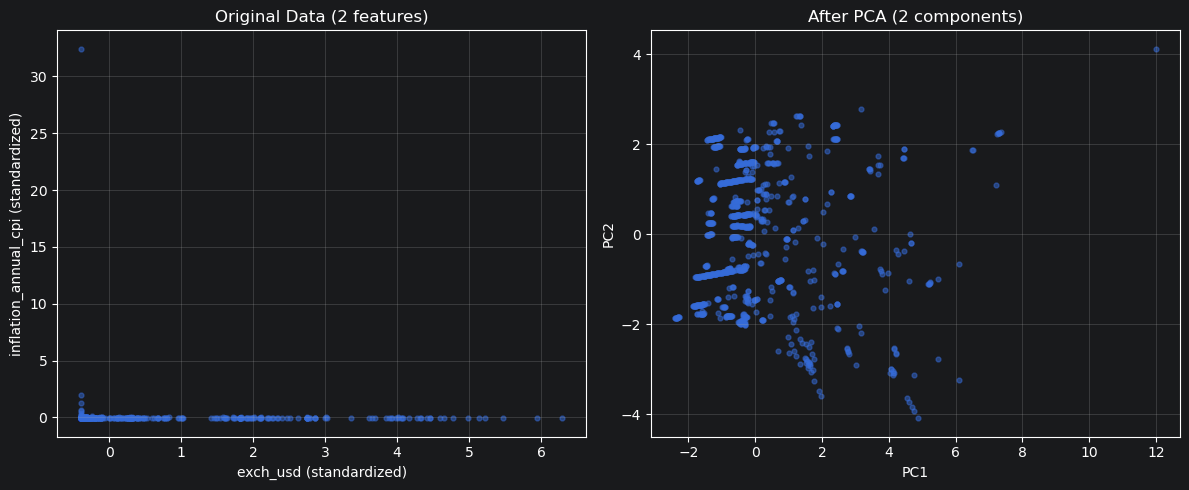

In [10]:
# Step 8: Visualize Before and After PCA
viz_components = 2
reduced_2d = standardized_data @ sorted_eigenvectors[:, :viz_components]

plt.figure(figsize=(12, 5))

# Plot original data (exchange rate vs inflation for economic interpretation)
plt.subplot(1, 2, 1)
plt.scatter(standardized_data[:, 3], standardized_data[:, 7], alpha=0.5, s=12)
plt.xlabel('exch_usd (standardized)')
plt.ylabel('inflation_annual_cpi (standardized)')
plt.title('Original Data (2 features)')
plt.grid(True, alpha=0.3)

# Plot reduced data after PCA
plt.subplot(1, 2, 2)
plt.scatter(reduced_2d[:, 0], reduced_2d[:, 1], alpha=0.5, s=12)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('After PCA (2 components)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

**Answer:** The left plot shows two raw macroeconomic indicators (exchange rate and inflation) with a wide, uneven spread, meaning crisis years and calm years overlap in that 2D view. The right plot compresses all 11 standardized indicators into PC1 and PC2, producing a tighter cloud where major joint shocks align along PC1. The PCA view is easier to scan for broad instability patterns, but individual feature meaning is less direct than in the original plot.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

**Answer:** I kept 9 components because that is the smallest number that reaches 90% cumulative explained variance on this dataset. The tradeoff is dimensionality versus fidelity: 9 components still remove 2 dimensions, giving moderate compression, while dropping below 90% would speed analysis and simplify plots but risk missing weaker yet policy-relevant signals such as rare debt-default combinations. Pushing to 95% would need 10 components and add little extra variance for one more dimension.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

**Answer:** For this African macroeconomic-crisis use case, reducing dimensions mainly loses country identity, banking-crisis labels, and fine-grained timing detail tied to single indicators. Variance tied to isolated events (for example a brief currency shock uncorrelated with inflation) can be pushed into discarded components. We also lose direct readability of variables like `domestic_debt_in_default` and `independence`, which analysts need when linking PCA clusters to specific policy levers.


### Task 3: Optimized PCA for Performance
For larger datasets, computing the full covariance matrix and eigendecomposition can be expensive. A common optimization is to use SVD on the centered data matrix, which is numerically stable and avoids explicitly forming an `(d x d)` covariance matrix when `n >> d`.

In [11]:
def fast_pca(data_matrix, variance_threshold=0.90, n_components=None):
    """Optimized PCA using SVD (numpy only)."""
    centered = data_matrix - np.mean(data_matrix, axis=0)
    n_samples = centered.shape[0]

    # SVD is efficient when feature count is moderate and scales well for larger sample sizes
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)

    eigenvalues = (singular_values ** 2) / (n_samples - 1)
    eigenvectors = vt.T

    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
    cumulative_variance = np.cumsum(explained_variance_ratio)

    if n_components is None:
        n_components = int(np.argmax(cumulative_variance >= variance_threshold) + 1)

    projected = centered @ eigenvectors[:, :n_components]
    return projected, eigenvalues[:n_components], eigenvectors[:, :n_components], explained_variance_ratio

optimized_reduced, opt_eigenvalues, opt_eigenvectors, opt_variance_ratio = fast_pca(
    standardized_data, variance_threshold=0.90
)

print(f'Optimized reduced shape: {optimized_reduced.shape}')
print(f'Optimized cumulative variance: {np.cumsum(opt_variance_ratio)[optimized_reduced.shape[1] - 1]:.4f}')
optimized_reduced[:5]

Optimized reduced shape: (1059, 9)
Optimized cumulative variance: 0.9306


array([[ 0.67049747, -2.60438893,  3.19616247,  3.54298457, -2.63795498,
         0.24579577,  0.4909085 , -0.885057  , -1.11028208],
       [-2.40193522, -1.86094565,  2.17402441,  0.03593051, -1.1490744 ,
         0.81340709,  0.64383351, -0.41311003, -0.6636525 ],
       [-2.39370688, -1.86018369,  2.160754  ,  0.03625053, -1.13678394,
         0.8039997 ,  0.64618489, -0.41115612, -0.65772488],
       [-2.38314765, -1.85849119,  2.15102266,  0.03578008, -1.1242739 ,
         0.80460755,  0.63833012, -0.40341922, -0.65153577],
       [-2.37471889, -1.85764978,  2.13805559,  0.03603226, -1.11196451,
         0.79606043,  0.63980581, -0.40096818, -0.64558576]])

In [12]:
# Validate optimized implementation against covariance-based PCA
manual_projection = standardized_data @ sorted_eigenvectors[:, :optimized_reduced.shape[1]]

# Eigenvectors may differ by sign, so compare absolute projections
projection_difference = np.max(np.abs(np.abs(manual_projection) - np.abs(optimized_reduced)))
print(f'Max absolute difference between methods: {projection_difference:.6f}')
print('Methods match' if projection_difference < 1e-8 else 'Methods differ')

Max absolute difference between methods: 0.000000
Methods match


#### Performance benchmark: covariance+eigh vs SVD

In [13]:
def covariance_pca(data_matrix, variance_threshold=0.90):
    """Reference PCA via covariance matrix and eigendecomposition."""
    cov = np.cov(data_matrix, rowvar=False)
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:, order]
    explained = vals / np.sum(vals)
    cumulative = np.cumsum(explained)
    n_components = int(np.argmax(cumulative >= variance_threshold) + 1)
    projected = data_matrix @ vecs[:, :n_components]
    return projected, n_components


def time_pca(fn, data_matrix, repeats=30):
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        fn(data_matrix)
        times.append(time.perf_counter() - start)
    return np.mean(times), np.std(times)


repeats = 30
cov_mean, cov_std = time_pca(covariance_pca, standardized_data, repeats=repeats)
svd_mean, svd_std = time_pca(fast_pca, standardized_data, repeats=repeats)
speedup = cov_mean / svd_mean

print(f'Covariance+eigh: {cov_mean*1000:.2f} ms ± {cov_std*1000:.2f} ms (n={repeats})')
print(f'SVD fast_pca:    {svd_mean*1000:.2f} ms ± {svd_std*1000:.2f} ms (n={repeats})')
print(f'SVD speedup:     {speedup:.2f}x faster')

# Scaling check: more samples (n >> d) on real feature count
rng = np.random.default_rng(42)
large_n_data = rng.standard_normal((20000, standardized_data.shape[1]))
large_n_cov_mean, _ = time_pca(covariance_pca, large_n_data, repeats=10)
large_n_svd_mean, _ = time_pca(fast_pca, large_n_data, repeats=10)
print(f'More rows (20000 x {large_n_data.shape[1]}): covariance {large_n_cov_mean*1000:.1f} ms, SVD {large_n_svd_mean*1000:.1f} ms')

# High-dimensional case (large d): SVD avoids building a (d x d) covariance matrix
high_d_data = rng.standard_normal((500, 2500))
hd_cov_mean, _ = time_pca(covariance_pca, high_d_data, repeats=5)
hd_svd_mean, _ = time_pca(fast_pca, high_d_data, repeats=5)
print(f'High dimensions (500 x 2500): covariance {hd_cov_mean*1000:.1f} ms, SVD {hd_svd_mean*1000:.1f} ms, speedup {hd_cov_mean/hd_svd_mean:.2f}x')

Covariance+eigh: 0.09 ms ± 0.07 ms (n=30)
SVD fast_pca:    0.17 ms ± 0.03 ms (n=30)
SVD speedup:     0.54x faster
More rows (20000 x 13): covariance 0.9 ms, SVD 17.5 ms
High dimensions (500 x 2500): covariance 764.0 ms, SVD 257.3 ms, speedup 2.97x


On our 13-feature crisis data, covariance+eigh is competitive because `d` is small. The synthetic `500 x 2500` test shows where SVD helps: when `d` is large, skipping the explicit `(d x d)` covariance matrix reduces cost and memory.